AUTOENCODER

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2206 - val_loss: 0.1390
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1239 - val_loss: 0.1116
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1072 - val_loss: 0.1016
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0997 - val_loss: 0.0962
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0954 - val_loss: 0.0923
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0922 - val_loss: 0.0895
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0896 - val_loss: 0.0875
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0875 - val_loss: 0.0855
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0859 - val_loss: 0.0840
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0845 - val_loss: 0.0831
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0835 - val_loss: 0.0825
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

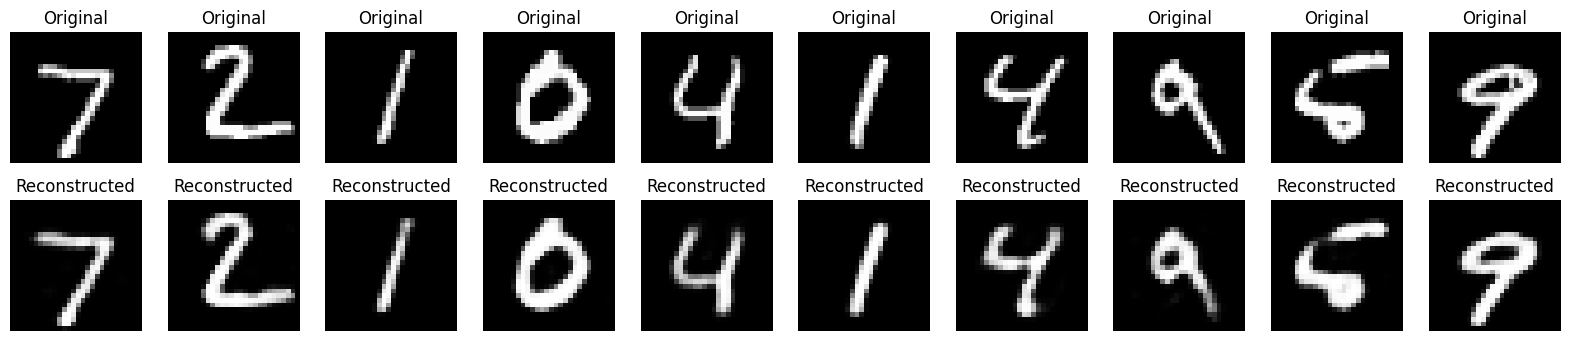

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. BUILD AUTOENCODER
# -----------------------------
input_dim = 784
encoding_dim = 64   # compressed size

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_layer, decoded)

# -----------------------------
# 3. COMPILE
# -----------------------------
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy')

# -----------------------------
# 4. TRAIN
# -----------------------------
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# -----------------------------
# 5. RECONSTRUCTION
# -----------------------------
decoded_imgs = autoencoder.predict(x_test[:10])

# -----------------------------
# 6. VISUALIZATION
# -----------------------------
plt.figure(figsize=(20,4))

for i in range(10):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

UNDERCOMPLETE

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2777 - val_loss: 0.1923
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1724 - val_loss: 0.1536
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1438 - val_loss: 0.1328
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1274 - val_loss: 0.1200
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1169 - val_loss: 0.1117
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1100 - val_loss: 0.1060
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1052 - val_loss: 0.1020
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1017 - val_loss: 0.0989
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0992 - val_loss: 0.0970
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0976 - val_loss: 0.0956
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


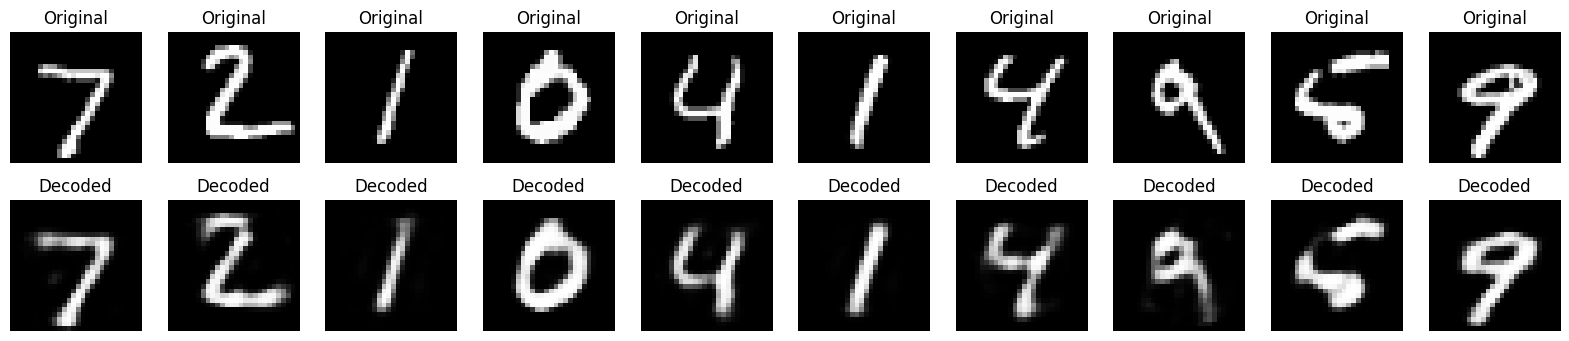

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# 1. Load Data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Model (UNDERCOMPLETE)
input_dim = 784
encoding_dim = 32   # SMALL → compression

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

# 3. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 5. Predict
decoded_imgs = autoencoder.predict(x_test[:10])

# 6. Visualize
plt.figure(figsize=(20,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.show()

OVERCOMPLETE

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1374 - val_loss: 0.0813
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0750 - val_loss: 0.0701
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0690 - val_loss: 0.0673
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0669 - val_loss: 0.0660
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0660 - val_loss: 0.0654
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0654 - val_loss: 0.0649
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0646 - val_loss: 0.0644
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0644 - val_loss: 0.0642
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0642 - val_loss: 0.0644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


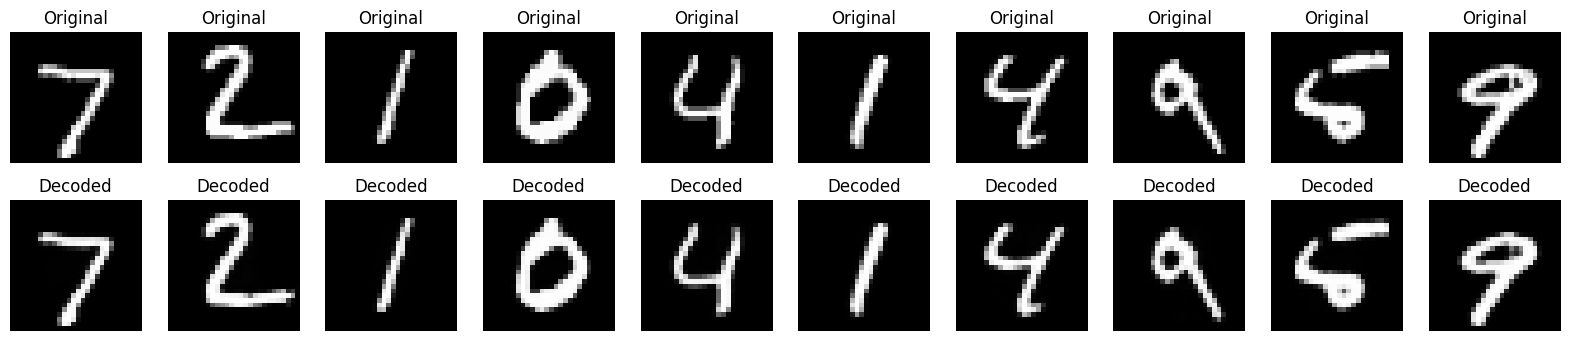

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# 1. Load Data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Model (OVERCOMPLETE)
input_dim = 784
encoding_dim = 1024   # LARGE → no compression

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

# 3. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 5. Predict
decoded_imgs = autoencoder.predict(x_test[:10])

# 6. Visualize
plt.figure(figsize=(20,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.show()

REGULARIZATION

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.2748 - val_loss: 0.1667
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1642 - val_loss: 0.1435
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1520 - val_loss: 0.1342
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1463 - val_loss: 0.1291
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1428 - val_loss: 0.1249
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1403 - val_loss: 0.1222
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1382 - val_loss: 0.1201
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1364 - val_loss: 0.1180
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1349 - val_loss: 0.1153
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1334 - val_loss: 0.1145
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1322 - val_loss: 0.1132
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

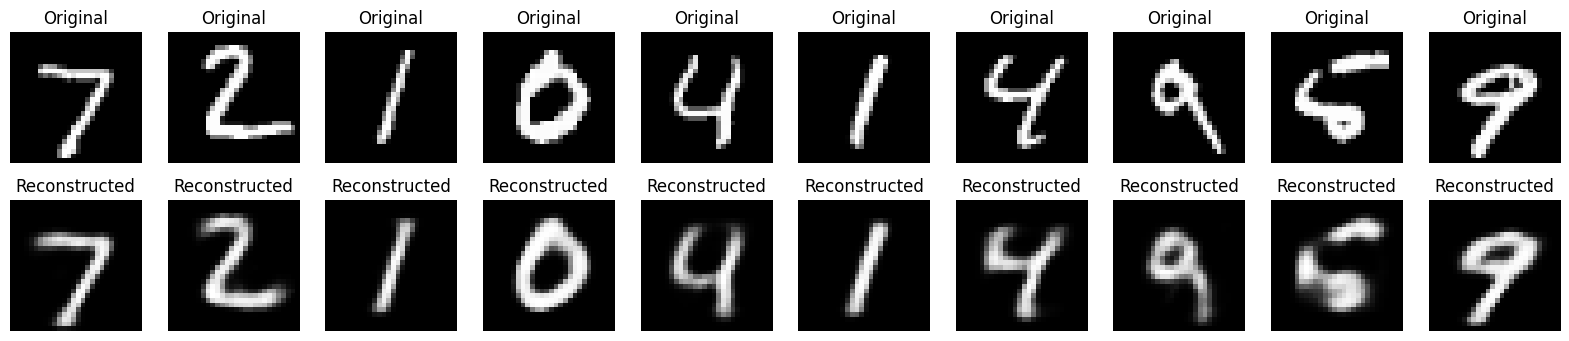

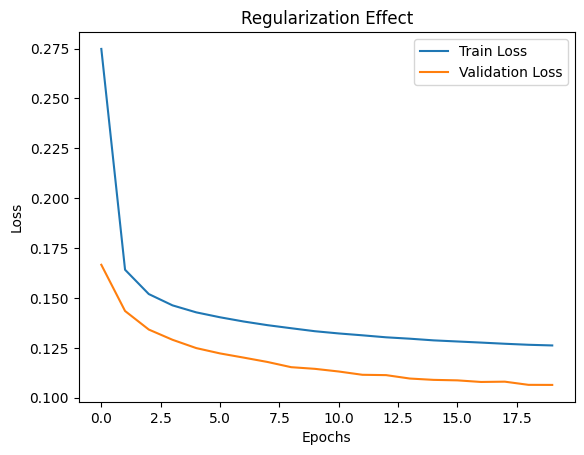

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. BUILD REGULARIZED AUTOENCODER
# -----------------------------
input_dim = 784
encoding_dim = 64

input_layer = Input(shape=(input_dim,))

# 🔹 Add Noise (Denoising AE)
noisy_input = GaussianNoise(0.2)(input_layer)

# 🔹 Encoder with L2 Regularization + Dropout
encoded = Dense(128, activation='relu',
                kernel_regularizer=regularizers.l2(0.001))(noisy_input)
encoded = Dropout(0.3)(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# 🔹 Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_layer, decoded)

# -----------------------------
# 3. COMPILE
# -----------------------------
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy')

# -----------------------------
# 4. TRAIN
# -----------------------------
history = autoencoder.fit(x_train, x_train,
                          epochs=20,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test, x_test))

# -----------------------------
# 5. RECONSTRUCTION
# -----------------------------
decoded_imgs = autoencoder.predict(x_test[:10])

# -----------------------------
# 6. VISUALIZATION
# -----------------------------
plt.figure(figsize=(20,4))

for i in range(10):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

# -----------------------------
# 7. LOSS GRAPH
# -----------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Regularization Effect")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

DENOISING

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2332 - val_loss: 0.1604
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1443 - val_loss: 0.1312
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1264 - val_loss: 0.1204
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1175 - val_loss: 0.1129
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1123 - val_loss: 0.1090
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1088 - val_loss: 0.1060
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1062 - val_loss: 0.1040
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1042 - val_loss: 0.1025
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1027 - val_loss: 0.1008
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1011 - val_loss: 0.0998
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0999 - val_loss: 0.0987
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

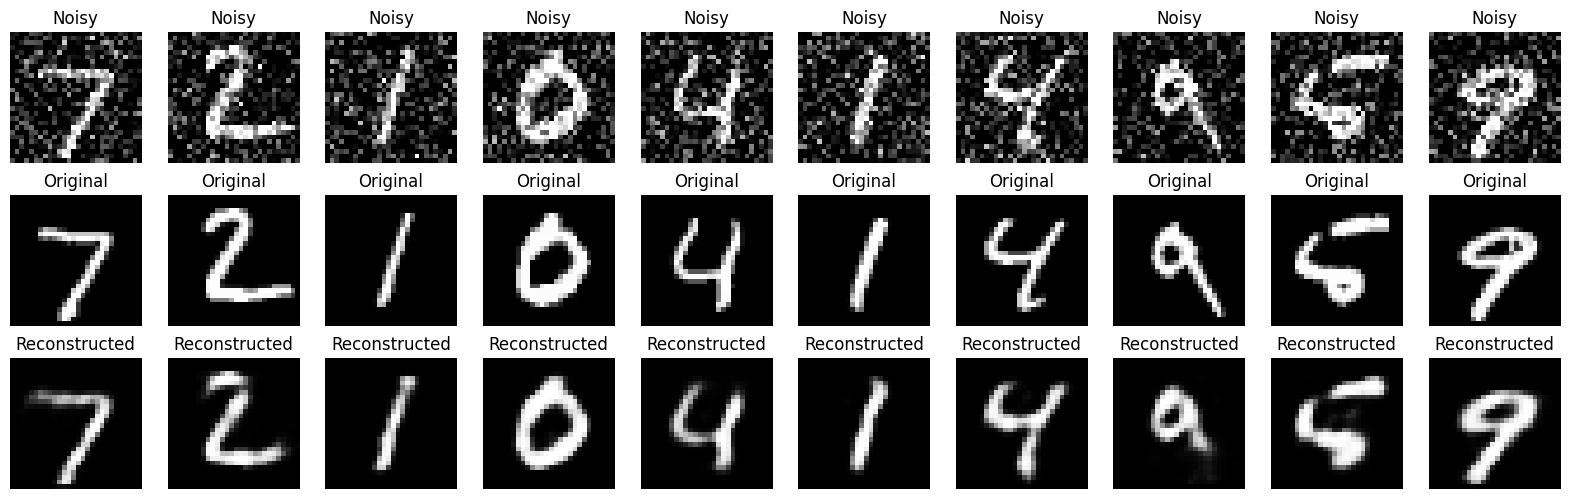

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. ADD NOISE
# -----------------------------
noise_factor = 0.3  # try 0.1, 0.3, 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# keep values in range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# -----------------------------
# 3. BUILD MODEL
# -----------------------------
input_dim = 784
encoding_dim = 64

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# -----------------------------
# 4. COMPILE
# -----------------------------
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy')

# -----------------------------
# 5. TRAIN
# -----------------------------
autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# -----------------------------
# 6. PREDICT
# -----------------------------
decoded_imgs = autoencoder.predict(x_test_noisy[:10])

# -----------------------------
# 7. VISUALIZE
# -----------------------------
plt.figure(figsize=(20,6))

for i in range(10):
    # Noisy input
    plt.subplot(3,10,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Clean original
    plt.subplot(3,10,i+11)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,10,i+21)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Demonstrate PCA with AE

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


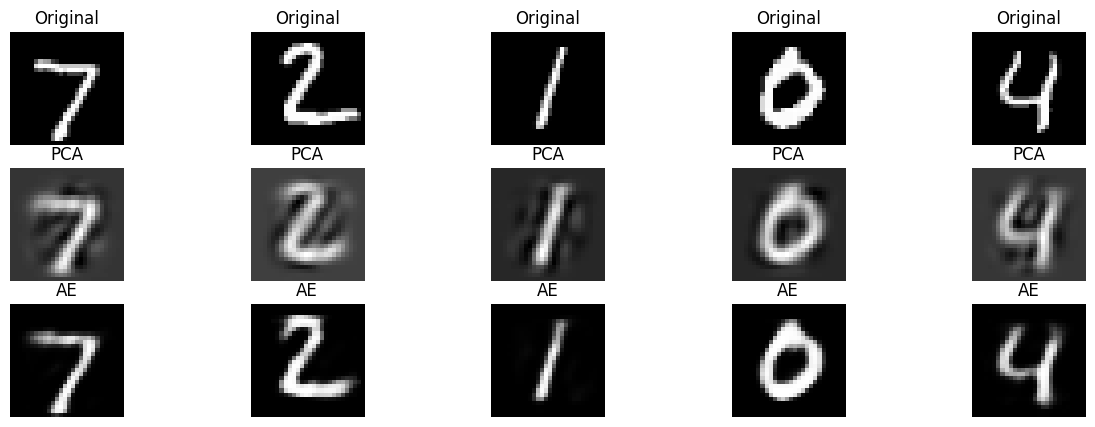

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=32)
x_test_pca = pca.fit_transform(x_test)
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# -----------------------------
# Autoencoder
# -----------------------------
input_layer = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

decoded_imgs = autoencoder.predict(x_test)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(15,5))

for i in range(5):
    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA
    plt.subplot(3,5,i+6)
    plt.imshow(x_test_pca_recon[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    # AE
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("AE")
    plt.axis('off')

plt.show()

Implement Sparse AE and Contractive AE

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.3598 - val_loss: 0.2604
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.2564 - val_loss: 0.2514
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2482 - val_loss: 0.2449
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2440 - val_loss: 0.2424
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2415 - val_loss: 0.2390
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2364 - val_loss: 0.2335
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.2332 - val_loss: 0.2333
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2318 - val_loss: 0.2312
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2300 - val_loss: 0.2287
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2274 - val_loss: 0.2255
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


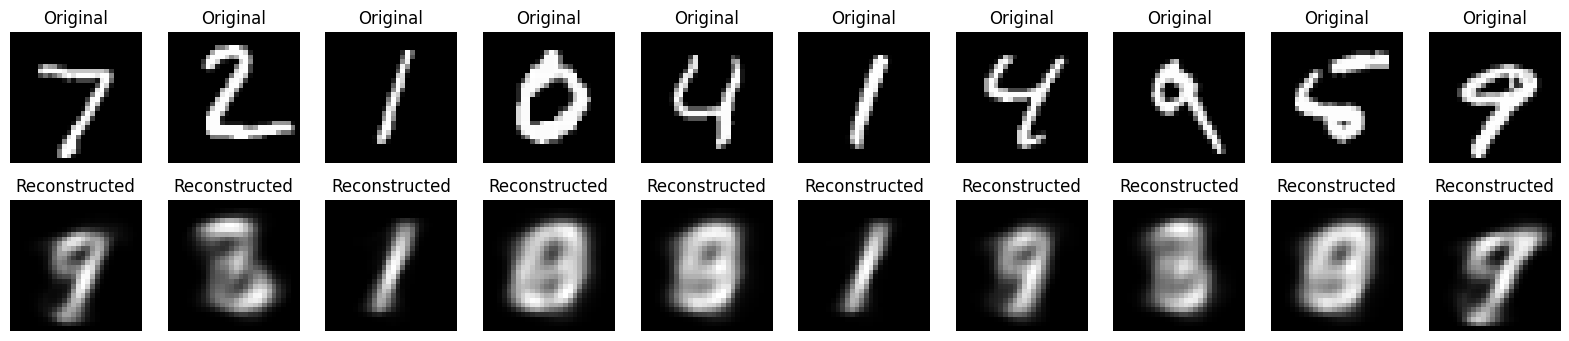

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# SPARSE AUTOENCODER
# -----------------------------
input_layer = Input(shape=(784,))

encoded = Dense(128, activation='relu',
                activity_regularizer=regularizers.l1(1e-4))(input_layer)

encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

sparse_ae = Model(input_layer, decoded)

# -----------------------------
# COMPILE & TRAIN
# -----------------------------
sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

sparse_ae.fit(x_train, x_train,
              epochs=10,
              batch_size=256,
              validation_data=(x_test, x_test))

# -----------------------------
# VISUALIZATION
# -----------------------------
decoded_imgs = sparse_ae.predict(x_test[:10])

plt.figure(figsize=(20,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()